In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn



In [ ]:
df_overview = pd.read_csv(r"C:\Data_Projects\Data_4620\Homework_2_4620\Data_set_hw2\synthetic_traffic_benchmark_200k.csv",
                          keep_default_na=False, na_values=[""])

print(f"shape: {df_overview.shape}")
print(df_overview.info())

shape: (200000, 29)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Record_ID                            200000 non-null  str    
 1   Timestamp                            200000 non-null  str    
 2   Date                                 200000 non-null  str    
 3   Hour                                 200000 non-null  int64  
 4   Month                                200000 non-null  int64  
 5   Day_of_Week                          200000 non-null  str    
 6   Time_of_Day                          200000 non-null  str    
 7   Is_Holiday                           200000 non-null  int64  
 8   Area_Type                            200000 non-null  str    
 9   Road_Type                            200000 non-null  str    
 10  Intersection_Type                    200000 non-null  str    
 11  Spee

In [42]:
str_cols = df_overview.select_dtypes(include='object').columns
str_cols = str_cols.drop(["Record_ID", "Date", "Timestamp"])

for col in str_cols:
    print("-"*1000)
    print(f"Column: {col}")
    print(df_overview[col].value_counts())

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

C:\Users\Flami\AppData\Local\Temp\ipykernel_6636\872586549.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_overview.select_dtypes(include='object').columns


In [43]:
int_cols = df_overview.select_dtypes(include=['int', 'float']).columns

for col in int_cols:
    print("-"*1000)
    print(f"Column: {col}")
    print(df_overview[col].value_counts())

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Goal: 
- To classify the severity of the Emergency based off features or details given the emergency call. 

In [44]:
df_overview.Accident_Severity.value_counts()

Accident_Severity
No Accident    191769
Minor            5377
Moderate         2358
Severe            348
Fatal             148
Name: count, dtype: int64

# Note (Target Variable)
The issue in front of us is a class imbalance issue. The ratio of" accident types" to "No accidents" is severely imbalance. Thus trying to train a model to be able to identify these different types of accidents may result in a bias towards predicting an accident to being not having any severity.


## Data Cleaning -- 
Remove Unwanted Features: 
- Record ID
- Timestamp
- Date


Remove data-leakage features (only known after an accident happens, so they give the answer to the model):
- Accident_ Occured --- Data_leakage by giving answer to machine
- Collision_Type --- Data_leakage by giving answer to machine (null exactly when there is no accident)
- Vehicles_Involved --- Data_leakage by giving answer to machine (0 exactly when there is no accident) *(FIXED: was missing from list)*
- Dispatch Priority --- Data_leakage by giving answer to machine
- Actual Response Time min --- Data_leakage by giving answer to machine
- Road Closure Duration -- Data_leakage by giving answer to machine

*(FIXED: Collision_Type was listed twice — merged into one entry)*

## Data Preperation

In [45]:
# Drop the columns we said above
drop_cols = ["Record_ID", "Timestamp", "Date",
             "Accident_Occurred", "Collision_Type", "Vehicles_Involved",
             "Dispatch_Priority", "Actual_Response_Time_min", "Road_Closure_Duration_min"]
df = df_overview.drop(columns=drop_cols)

In [46]:
df["Weather"] = df["Weather"].str.strip().str.title()
df.loc[df["Recorded_Speed_kmh"] >= 999, "Recorded_Speed_kmh"] = np.nan

# Encode target as integers 0-4 (ordered by severity)
class_names = ["No Accident", "Minor", "Moderate", "Severe", "Fatal"] # used to give shape for NN output layer (n_classes) and for dummy variables
y = df["Accident_Severity"].map({name: i for i, name in enumerate(class_names)}).values # to create the dummy variables 
X = df.drop(columns=["Accident_Severity"])

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)


## Mapping and filling NA values

In [48]:
cat_cols = ["Day_of_Week", "Time_of_Day", "Area_Type", "Road_Type",
            "Intersection_Type", "Weather", "Road_Condition", "Vehicle_Type"]
num_cols = [c for c in X.columns if c not in cat_cols]

# One-hot encode categoricals
X = pd.get_dummies(X, columns=cat_cols, dtype=float)

# Stratified split keeps the rare classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Impute missing numerics with TRAIN medians (Visibility_m, Driver_Experience_yrs, Recorded_Speed_kmh)
medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians) 
X_test[num_cols] = X_test[num_cols].fillna(medians)

# Standardize numerics using TRAIN statistics only
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Features:", X_train.shape[1], "| Train:", len(X_train), "| Test:", len(X_test))

Features: 47 | Train: 160000 | Test: 40000


In [55]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # CrossEntropyLoss wants integer class labels
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)

# Evaluation

In [56]:
def evaluate(X_t, y_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        loss = criterion(logits, y_t).item()  
        preds = logits.argmax(dim=1).numpy()
    err = 1 - (preds == y_t.numpy()).mean()
    return loss, err, preds

## Coding the Neaural Network #1

In [57]:
class BaseNN(nn.Module):
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, n_classes) 
        )
    def forward(self, x):
        return self.net(x)

model = BaseNN(X_train_tensor.shape[1], len(class_names))
criterion = nn.CrossEntropyLoss() # no class weights
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # no momentum, no weight decay
EPOCHS = 30

# Epoch Count And Training tracker

In [58]:
# FIXED: re-create the model + optimizer here so re-running this cell always starts from fresh weights
# (the crashed run had already trained 1 epoch, so re-running without this would continue from those weights)
torch.manual_seed(SEED)
model = BaseNN(X_train_tensor.shape[1], len(class_names))
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

history = {"train_loss": [], "test_loss": [], "train_err": [], "test_err": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_err, _ = evaluate(X_train_tensor, y_train_tensor)
    te_loss, te_err, _ = evaluate(X_test_tensor, y_test_tensor)
    history["train_loss"].append(tr_loss); history["test_loss"].append(te_loss)
    history["train_err"].append(tr_err);   history["test_err"].append(te_err)
    print(f"Epoch {epoch} | train loss {tr_loss} err {tr_err} | test loss {te_loss} err {te_err}")

Epoch 1 | train loss 0.21303574740886688 err 0.041156250000000005 | test loss 0.21351701021194458 err 0.04115000000000002
Epoch 2 | train loss 0.2042883336544037 err 0.041156250000000005 | test loss 0.20479807257652283 err 0.04115000000000002
Epoch 3 | train loss 0.20106880366802216 err 0.041156250000000005 | test loss 0.20160141587257385 err 0.04115000000000002
Epoch 4 | train loss 0.19946838915348053 err 0.041156250000000005 | test loss 0.20002682507038116 err 0.04115000000000002
Epoch 5 | train loss 0.19851161539554596 err 0.041156250000000005 | test loss 0.1990472376346588 err 0.04115000000000002
Epoch 6 | train loss 0.1978643238544464 err 0.041156250000000005 | test loss 0.19840946793556213 err 0.04115000000000002
Epoch 7 | train loss 0.19741809368133545 err 0.041156250000000005 | test loss 0.1979590505361557 err 0.04115000000000002
Epoch 8 | train loss 0.19707772135734558 err 0.041156250000000005 | test loss 0.1976059526205063 err 0.04115000000000002
Epoch 9 | train loss 0.196811

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

_, tr_err, tr_preds = evaluate(X_train_tensor, y_train_tensor)
_, te_err, te_preds = evaluate(X_test_tensor, y_test_tensor)

print(f"Train error: {tr_err}   Test error: {te_err}")
print(f"Always-predict-'No Accident' error: {(y_test != 0).mean()}")
print(f"Train macro F1: {f1_score(y_train, tr_preds, average='macro')}")
print(f"Test  macro F1: {f1_score(y_test, te_preds, average='macro')}\n")
print(classification_report(y_test, te_preds, labels=range(5), target_names=class_names, zero_division=0))
print(confusion_matrix(y_test, te_preds, labels=range(5)))

Train error: 0.041156250000000005   Test error: 0.04115000000000002
Always-predict-'No Accident' error: 0.04115
Train macro F1: 0.19579790373785555
Test  macro F1: 0.19579855527477857

              precision    recall  f1-score   support

 No Accident       0.96      1.00      0.98     38354
       Minor       0.00      0.00      0.00      1075
    Moderate       0.00      0.00      0.00       471
      Severe       0.00      0.00      0.00        70
       Fatal       0.00      0.00      0.00        30

    accuracy                           0.96     40000
   macro avg       0.19      0.20      0.20     40000
weighted avg       0.92      0.96      0.94     40000

[[38354     0     0     0     0]
 [ 1075     0     0     0     0]
 [  471     0     0     0     0]
 [   70     0     0     0     0]
 [   30     0     0     0     0]]


# Notes: 
The model worked well on determining the emergency's severity. This is a good first step however there are a few issues needed to address.
1. There is no Class balance. This is an issue because the model is trained with bias with fitting more onto predicing whethere a severity of an emergency is "No Accident" This is a problem because its causing the model to underfit. 
2. Slow Optimization, the training loss is slow and not lowering as fast as we expected. 

# Neural Network #2 -- Using SMOTE onto dataset

In [67]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, ConfusionMatrixDisplay

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

X_train_sm_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_sm_tensor = torch.tensor(y_train_sm, dtype=torch.long)

train_loader_sm = DataLoader(TensorDataset(X_train_sm_tensor, y_train_sm_tensor), batch_size=BATCH_SIZE, shuffle=True)


Before SMOTE: [153415   4302   1887    278    118]
After SMOTE: [153415 153415 153415 153415 153415]


In [65]:
torch.manual_seed(SEED)
model = BaseNN(X_train_tensor.shape[1], len(class_names))
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # same parameters
history_sm = {"train_loss": [], "test_loss": [], "train_err": [], "test_err": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader_sm:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    tr_loss, tr_err, _ = evaluate(X_train_sm_tensor, y_train_sm_tensor)   # loss on what it trained on
    te_loss, te_err, _ = evaluate(X_test_tensor, y_test_tensor)
    history_sm["train_loss"].append(tr_loss); history_sm["test_loss"].append(te_loss)
    history_sm["train_err"].append(tr_err);   history_sm["test_err"].append(te_err)
    print(f"Epoch {epoch} | train loss {tr_loss} err {tr_err} | test loss {te_loss} err {te_err}")

Epoch 1 | train loss 1.102382779121399 err 0.476304142358961 | test loss 1.2810041904449463 err 0.5206
Epoch 2 | train loss 1.0087833404541016 err 0.42371867157709486 | test loss 1.2461962699890137 err 0.529975
Epoch 3 | train loss 0.9206861853599548 err 0.38438223120294623 | test loss 1.2303824424743652 err 0.5441
Epoch 4 | train loss 0.8457180857658386 err 0.3507544894567024 | test loss 1.1902492046356201 err 0.5231
Epoch 5 | train loss 0.7843061089515686 err 0.32743864680767854 | test loss 1.1314539909362793 err 0.49412500000000004
Epoch 6 | train loss 0.7346180081367493 err 0.30826842225336504 | test loss 1.1348626613616943 err 0.511325
Epoch 7 | train loss 0.6942648887634277 err 0.28918293517583027 | test loss 1.1159368753433228 err 0.50405
Epoch 8 | train loss 0.6611813902854919 err 0.277709480819998 | test loss 1.0894348621368408 err 0.494575
Epoch 9 | train loss 0.6346688866615295 err 0.2662034351269432 | test loss 1.1125867366790771 err 0.5076499999999999
Epoch 10 | train loss

In [66]:
_, te_err, te_preds = evaluate(X_test_tensor, y_test_tensor)
print(f"Test error: {te_err:.4f}   Test macro F1: {f1_score(y_test, te_preds, average='macro')}\n")
print(classification_report(y_test, te_preds, labels=range(5), target_names=class_names, zero_division=0))
print(confusion_matrix(y_test, te_preds, labels=range(5)))

Test error: 0.3826   Test macro F1: 0.18522027509876862

              precision    recall  f1-score   support

 No Accident       0.97      0.63      0.76     38354
       Minor       0.06      0.48      0.10      1075
    Moderate       0.02      0.25      0.04       471
      Severe       0.01      0.07      0.01        70
       Fatal       0.00      0.03      0.01        30

    accuracy                           0.62     40000
   macro avg       0.21      0.29      0.19     40000
weighted avg       0.93      0.62      0.73     40000

[[24057  8292  5114   603   288]
 [  442   516   111     4     2]
 [  230   101   118    14     8]
 [   27     7    26     5     5]
 [    9     0    13     7     1]]


# Neaural Network #3 (Testing for the best Optimization)
## NOTE: we are combining these optimizer + SMOTE
- SGD
- SGD + Momentum
- RMSprop
- Adam

This is our final model. We want to see how the optimizer will improve our model's ability to classify different emergency responses severity. 

SGD
Epoch  5 | train loss 0.7843 err 0.3274 | test loss 1.1315 err 0.4941
Epoch 10 | train loss 0.6126 err 0.2592 | test loss 1.0767 err 0.4984
Epoch 15 | train loss 0.5444 err 0.2346 | test loss 0.9997 err 0.4552
Epoch 20 | train loss 0.5097 err 0.2171 | test loss 0.9030 err 0.4073
Epoch 25 | train loss 0.4804 err 0.2049 | test loss 0.8861 err 0.3889
Epoch 30 | train loss 0.4572 err 0.1925 | test loss 0.8745 err 0.3826

----- SGD RESULTS -----
Test accuracy: 0.6174   Test error: 0.3826   Macro F1: 0.1852

              precision    recall  f1-score   support

 No Accident       0.97      0.63      0.76     38354
       Minor       0.06      0.48      0.10      1075
    Moderate       0.02      0.25      0.04       471
      Severe       0.01      0.07      0.01        70
       Fatal       0.00      0.03      0.01        30

    accuracy                           0.62     40000
   macro avg       0.21      0.29      0.19     40000
weighted avg       0.93      0.62      0.73     40000


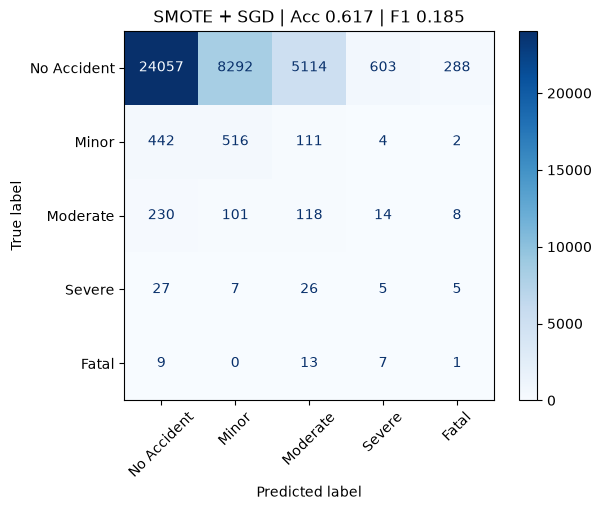

SGD+Momentum
Epoch  5 | train loss 0.4210 err 0.1791 | test loss 0.7402 err 0.3021
Epoch 10 | train loss 0.3478 err 0.1458 | test loss 0.7081 err 0.2780
Epoch 15 | train loss 0.3331 err 0.1397 | test loss 0.8512 err 0.3414
Epoch 20 | train loss 0.3166 err 0.1305 | test loss 0.8115 err 0.3148
Epoch 25 | train loss 0.2853 err 0.1194 | test loss 0.6451 err 0.2332
Epoch 30 | train loss 0.2853 err 0.1212 | test loss 0.6004 err 0.2033

----- SGD+Momentum RESULTS -----
Test accuracy: 0.7967   Test error: 0.2033   Macro F1: 0.2104

              precision    recall  f1-score   support

 No Accident       0.96      0.82      0.89     38354
       Minor       0.07      0.25      0.10      1075
    Moderate       0.02      0.15      0.04       471
      Severe       0.00      0.01      0.01        70
       Fatal       0.01      0.03      0.01        30

    accuracy                           0.80     40000
   macro avg       0.21      0.25      0.21     40000
weighted avg       0.93      0.80   

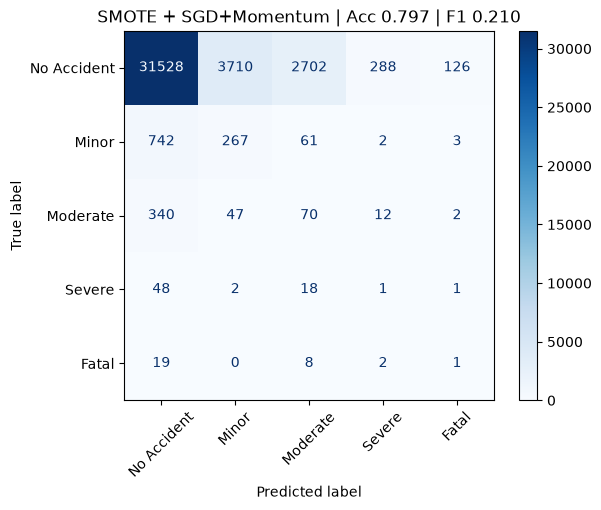

RMSprop
Epoch  5 | train loss 0.4108 err 0.1739 | test loss 0.6673 err 0.2511
Epoch 10 | train loss 0.3591 err 0.1548 | test loss 0.7438 err 0.3048
Epoch 15 | train loss 0.3377 err 0.1400 | test loss 0.7965 err 0.3081
Epoch 20 | train loss 0.3117 err 0.1308 | test loss 0.7758 err 0.3194
Epoch 25 | train loss 0.3110 err 0.1333 | test loss 0.4718 err 0.1342
Epoch 30 | train loss 0.3253 err 0.1358 | test loss 0.8684 err 0.3426

----- RMSprop RESULTS -----
Test accuracy: 0.6574   Test error: 0.3426   Macro F1: 0.1940

              precision    recall  f1-score   support

 No Accident       0.97      0.67      0.79     38354
       Minor       0.06      0.35      0.10      1075
    Moderate       0.02      0.29      0.04       471
      Severe       0.01      0.03      0.01        70
       Fatal       0.01      0.10      0.02        30

    accuracy                           0.66     40000
   macro avg       0.21      0.29      0.19     40000
weighted avg       0.93      0.66      0.76   

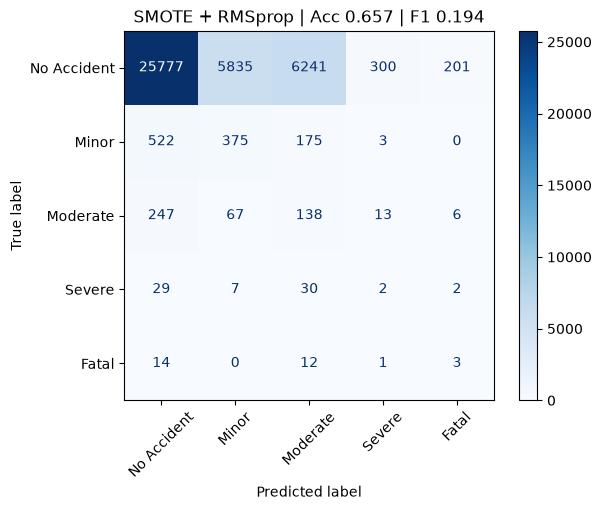

Adam
Epoch  5 | train loss 0.4255 err 0.1816 | test loss 0.6604 err 0.2580
Epoch 10 | train loss 0.3594 err 0.1505 | test loss 0.8504 err 0.3478
Epoch 15 | train loss 0.3260 err 0.1390 | test loss 0.5977 err 0.2139
Epoch 20 | train loss 0.3095 err 0.1323 | test loss 0.5036 err 0.1530
Epoch 25 | train loss 0.2922 err 0.1228 | test loss 0.6506 err 0.2469
Epoch 30 | train loss 0.2784 err 0.1165 | test loss 0.6176 err 0.2239

----- Adam RESULTS -----
Test accuracy: 0.7761   Test error: 0.2239   Macro F1: 0.2048

              precision    recall  f1-score   support

 No Accident       0.96      0.80      0.87     38354
       Minor       0.06      0.26      0.10      1075
    Moderate       0.03      0.15      0.04       471
      Severe       0.01      0.03      0.01        70
       Fatal       0.00      0.00      0.00        30

    accuracy                           0.78     40000
   macro avg       0.21      0.25      0.20     40000
weighted avg       0.93      0.78      0.84     4000

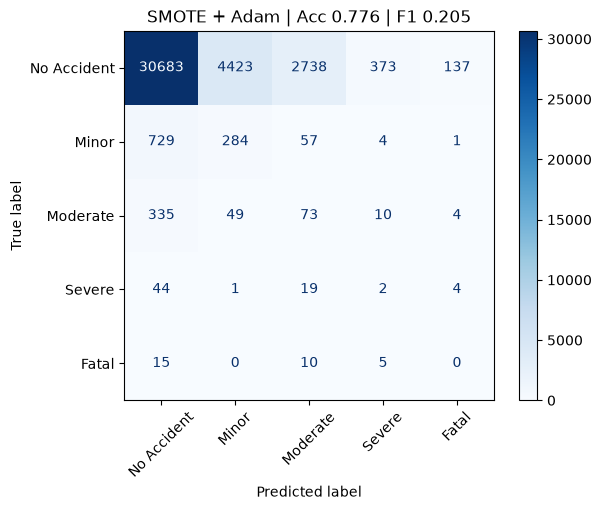

,train_loss,train_err,test_loss,test_err,test_acc,test_macro_F1,recall_No Accident,recall_Minor,recall_Moderate,recall_Severe,recall_Fatal
SGD,0.4572,0.1925,0.8745,0.3826,0.6174,0.1852,0.6272,0.4800,0.2505,0.0714,0.0333
SGD+Momentum,0.2853,0.1212,0.6004,0.2033,0.7967,0.2104,0.8220,0.2484,0.1486,0.0143,0.0333
RMSprop,0.3253,0.1358,0.8684,0.3426,0.6574,0.1940,0.6721,0.3488,0.2930,0.0286,0.1000
Adam,0.2784,0.1165,0.6176,0.2240,0.7760,0.2048,0.8000,0.2642,0.1550,0.0286,0.0000


In [ ]:
optimizers_to_try = {
    "SGD": lambda params: torch.optim.SGD(params, lr=0.01),
    "SGD+Momentum": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9),
    "RMSprop": lambda params: torch.optim.RMSprop(params, lr=0.001),
    "Adam": lambda params: torch.optim.Adam(params, lr=0.001)
}

all_histories = {}
results = {}

for opt_name, make_optimizer in optimizers_to_try.items():
    print(f"{opt_name}")
    torch.manual_seed(SEED)
    model = BaseNN(X_train_tensor.shape[1], len(class_names))
    optimizer = make_optimizer(model.parameters())

    hist = {"train_loss": [], "test_loss": [], "train_err": [], "test_err": []}
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb, in train_loader_sm:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Everything bellow this was to help me test out all of the different optimizers     
        tr_loss, tr_err, _ = evaluate(X_train_sm_tensor, y_train_sm_tensor)
        te_loss, te_err, _ = evaluate(X_test_tensor, y_test_tensor)
        hist["train_loss"].append(tr_loss); hist["test_loss"].append(te_loss)
        hist["train_err"].append(tr_err);   hist["test_err"].append(te_err)
        if epoch % 5 == 0:
            print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} err {tr_err:.4f} | test loss {te_loss:.4f} err {te_err:.4f}")



    _, te_err, te_preds = evaluate(X_test_tensor, y_test_tensor)
    te_acc = 1 - te_err
    te_f1 = f1_score(y_test, te_preds, average="macro")

    print(f"\n{opt_name} RESULTS:")
    print(f"Test accuracy: {te_acc}   Test error: {te_err}   Macro F1: {te_f1}\n")
    print(classification_report(y_test, te_preds, labels=range(5), target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, te_preds, labels=range(5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"SMOTE + {opt_name} | Acc {te_acc} | F1 {te_f1}")
    plt.show()

    # Helped by Claude:
    all_histories[opt_name] = hist
    results[opt_name] = {
        "train_loss": hist["train_loss"][-1],
        "train_err":  hist["train_err"][-1],
        "test_loss":  hist["test_loss"][-1],
        "test_err":   te_err,
        "test_acc":   te_acc,
        "test_macro_F1": te_f1,
        **{f"recall_{c}": r for c, r in zip(class_names,
            recall_score(y_test, te_preds, labels=range(5), average=None, zero_division=0))}
    }

results_df = pd.DataFrame(results).T.round(4)
results_df

 

# Notes & Conclusions: 
After using SMOTE to simulate and balance the classes for differents types of accident severitys, the model is now more fit and generalizable to classify different types of severities based on given features. However, testing our new training set set using SMOTE, it was expected we lost accuracy when applying a neaural network that uses "default" parameters.

To address this, I wanted to test different optimization methods: SGD (default), SGD + Momentum, RMSProp, and ADAM to see if this will improve accuracy, train loss, error, etc. As seen above the overall best performing model was SGD + Momentum. It had the best accuracy, 2nd best train loss. Moreover, it has the best F1-score, meaning it did a good job seperating the labels from one another. Last, it had the best recall score. 

 